## 1. Imports and helper functions


In [55]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error
import xgboost as xgb

import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline, QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

## 2- Load Dataset

In [56]:
df = pd.read_csv("fobhav_noisy.csv")


In [57]:
print("Dataset shape:", df.shape)
print(df.head(3))

Dataset shape: (57600000, 16)
  INSTRUMENT     SYMBOL    EXPIRY_DT  STRIKE_PR OPTION_TYP      OPEN  \
0     FUTIDX  BANKNIFTY  24-Sep-2020        0.0         XX  24900.05   
1     FUTIDX  BANKNIFTY  29-Oct-2020        0.0         XX  24937.55   
2     FUTIDX  BANKNIFTY  26-Nov-2020        0.0         XX  24989.95   

       HIGH       LOW    CLOSE  SETTLE_PR  CONTRACTS  VAL_INLAKH   OPEN_INT  \
0  25270.00  23371.00  23743.0    23743.0   504222.0  3051593.27  1432850.0   
1  25315.90  23391.90  23770.1    23770.1    10630.0    64526.57    91375.0   
2  25280.75  23437.15  23766.2    23766.2     1171.0     7088.68    14400.0   

   CHG_IN_OI    TIMESTAMP  Column_15  
0   -54500.0  31-AUG-2020        NaN  
1    19325.0  31-AUG-2020        NaN  
2     8400.0  31-AUG-2020        NaN  


## 3- Preprocessing

In [58]:
# Standardize column names to upper-case strings and trim whitespace
df.columns = [c.strip().upper() for c in df.columns] 

required_columns = [
    "INSTRUMENT", "SYMBOL", "EXPIRY_DT", "STRIKE_PR", "OPTION_TYP",
    "OPEN", "HIGH", "LOW", "CLOSE", "SETTLE_PR",
    "CONTRACTS", "VAL_INLAKH", "OPEN_INT", "CHG_IN_OI", "TIMESTAMP"
]


In [59]:
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError("Missing required columns: {}".format(missing))


In [60]:

df = df[df['INSTRUMENT'].astype(str).str.upper() == 'OPTIDX'].copy()
df = df[df['SYMBOL'].astype(str).str.upper().isin(['BANKNIFTY', 'NIFTY'])].copy()
df = df[df['OPTION_TYP'].isin(['CE', 'PE'])].copy()


In [61]:
print(df.head(10))

    INSTRUMENT     SYMBOL    EXPIRY_DT  STRIKE_PR OPTION_TYP    OPEN  \
414     OPTIDX  BANKNIFTY  03-Sep-2020    18100.0         CE     0.0   
415     OPTIDX  BANKNIFTY  03-Sep-2020    18200.0         CE     0.0   
416     OPTIDX  BANKNIFTY  03-Sep-2020    18300.0         CE  6236.6   
417     OPTIDX  BANKNIFTY  03-Sep-2020    18400.0         CE     0.0   
419     OPTIDX  BANKNIFTY  03-Sep-2020    18600.0         CE     0.0   
420     OPTIDX  BANKNIFTY  03-Sep-2020    18700.0         CE     0.0   
422     OPTIDX  BANKNIFTY  03-Sep-2020    18900.0         CE     0.0   
423     OPTIDX  BANKNIFTY  03-Sep-2020    19000.0         CE     0.0   
425     OPTIDX  BANKNIFTY  03-Sep-0220    19200.0         CE     0.0   
426     OPTIDX  BANKNIFTY  03-Sep-2020    19300.0         CE     0.0   

             HIGH          LOW         CLOSE    SETTLE_PR      CONTRACTS  \
414      0.000000     0.000000   6523.600000  5660.650000       0.000000   
415      0.000000     0.000000   3122.850000  5560.7000

In [62]:

df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], errors='coerce')
df['EXPIRY_DT'] = pd.to_datetime(df['EXPIRY_DT'], errors='coerce')


In [63]:

df = df.dropna(subset=['TIMESTAMP', 'EXPIRY_DT', 'STRIKE_PR', 'OPTION_TYP', 'OPEN_INT', 'CHG_IN_OI', 'CLOSE', 'CONTRACTS'])

numeric_cols = ['STRIKE_PR', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'SETTLE_PR', 'CONTRACTS', 'VAL_INLAKH', 'OPEN_INT', 'CHG_IN_OI']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=numeric_cols).reset_index(drop=True)

print('After preprocessing shape:', df.shape)
print(df[['INSTRUMENT', 'SYMBOL', 'OPTION_TYP', 'TIMESTAMP', 'EXPIRY_DT', 'STRIKE_PR']].head(5))

After preprocessing shape: (4435363, 16)
  INSTRUMENT     SYMBOL OPTION_TYP  TIMESTAMP  EXPIRY_DT  STRIKE_PR
0     OPTIDX  BANKNIFTY         CE 2020-08-31 2020-09-03    18100.0
1     OPTIDX  BANKNIFTY         CE 2020-08-31 2020-09-03    18200.0
2     OPTIDX  BANKNIFTY         CE 2020-08-31 2020-09-03    18300.0
3     OPTIDX  BANKNIFTY         CE 2020-08-31 2020-09-03    18400.0
4     OPTIDX  BANKNIFTY         CE 2020-08-31 2020-09-03    18600.0


## 4- Separate call and put aggregates by timestamp

In [66]:
df['PRICE'] = df['CLOSE'].fillna(df['SETTLE_PR'])

agg = df.groupby(['TIMESTAMP', 'SYMBOL', 'OPTION_TYP']).agg(
    total_open_int=('OPEN_INT', 'sum'),
    total_contracts=('CONTRACTS', 'sum'),
    avg_price=('PRICE', 'mean'),
    avg_chg_oi=('CHG_IN_OI', 'mean')
).reset_index()
print(agg)


       TIMESTAMP     SYMBOL OPTION_TYP  total_open_int  total_contracts  \
0      214-03-12      NIFTY         CE    0.000000e+00         0.000000   
1      214-03-12      NIFTY         PE    0.000000e+00         0.000000   
2      214-03-12      nifty         PE    0.000000e+00         0.000000   
3      214-03-13  BANKNIFTY         CE    0.000000e+00         0.000000   
4      214-03-13  BANKNIFTY         PE    0.000000e+00         0.000000   
...          ...        ...        ...             ...              ...   
24575 2200-08-28      NIFTY         PE    4.650000e+03   -288969.447315   
24576 2200-08-31  BANKNIFTY         CE    0.000000e+00         0.000000   
24577 2200-08-31  BANKNIFTY         PE    0.000000e+00    260234.580049   
24578 2200-08-31      NIFTY         PE   -5.770521e+07         0.000000   
24579 2200-08-31      nifty         PE    0.000000e+00         0.000000   

         avg_price  avg_chg_oi  
0       1524.30000         0.0  
1        862.50000         0.0  


In [67]:
df.columns

Index(['INSTRUMENT', 'SYMBOL', 'EXPIRY_DT', 'STRIKE_PR', 'OPTION_TYP', 'OPEN',
       'HIGH', 'LOW', 'CLOSE', 'SETTLE_PR', 'CONTRACTS', 'VAL_INLAKH',
       'OPEN_INT', 'CHG_IN_OI', 'TIMESTAMP', 'COLUMN_15', 'PRICE'],
      dtype='str')

In [68]:

agg_pivot = agg.pivot_table(
    index=['TIMESTAMP', 'SYMBOL'],
    columns='OPTION_TYP',
    values=['total_open_int', 'total_contracts', 'avg_price', 'avg_chg_oi'],
    fill_value=0
).reset_index()
agg_pivot.columns = ['_'.join(col).strip('_') for col in agg_pivot.columns.values] 

print(agg_pivot)


       TIMESTAMP     SYMBOL  avg_chg_oi_CE  avg_chg_oi_PE  avg_price_CE  \
0      214-03-12      NIFTY            0.0            0.0   1524.300000   
1      214-03-12      nifty            0.0            0.0      0.000000   
2      214-03-13  BANKNIFTY            0.0            0.0   1138.600000   
3      214-03-13      NIFTY            0.0            0.0   1464.066667   
4      214-03-14      NIFTY            0.0            0.0      0.000000   
...          ...        ...            ...            ...           ...   
14571 2200-08-27      NIFTY          450.0         4987.5    838.800000   
14572 2200-08-28      NIFTY            0.0            0.0    283.850000   
14573 2200-08-31  BANKNIFTY            0.0            0.0   1868.900000   
14574 2200-08-31      NIFTY            0.0            0.0      0.000000   
14575 2200-08-31      nifty            0.0            0.0      0.000000   

       avg_price_PE  total_contracts_CE  total_contracts_PE  \
0         862.50000            0.000

In [70]:
for col in ['total_open_int_CE', 'total_open_int_PE', 'total_contracts_CE', 'total_contracts_PE', 'avg_price_CE', 'avg_price_PE', 'avg_chg_oi_CE', 'avg_chg_oi_PE']:
    if col not in agg_pivot.columns:
        agg_pivot[col] = 0.0

agg_pivot = agg_pivot.sort_values(['TIMESTAMP', 'SYMBOL']).reset_index(drop=True)
print('Aggregated shape:', agg_pivot.shape)

agg_pivot.head(10)


Aggregated shape: (14576, 10)


,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE
0,214-03-12,NIFTY,0.0,0.000000e+00,1524.300000,862.500000,0.000000,0.000000,0.0,0.000000e+00
1,214-03-12,nifty,0.0,0.000000e+00,0.000000,535.050000,0.000000,0.000000,0.0,0.000000e+00
2,214-03-13,BANKNIFTY,0.0,0.000000e+00,1138.600000,16395.402710,0.000000,0.000000,0.0,0.000000e+00
3,214-03-13,NIFTY,0.0,0.000000e+00,1464.066667,0.050000,-254760.625284,0.000000,53000.0,0.000000e+00
4,214-03-14,NIFTY,0.0,0.000000e+00,0.000000,1066.650000,0.000000,231966.656939,0.0,0.000000e+00
5,214-03-18,NIFTY,0.0,3.610000e+04,0.000000,184.150000,0.000000,1510.000000,0.0,1.453500e+05
6,214-03-19,NIFTY,0.0,1.190247e+06,0.000000,314.200000,0.000000,0.000000,0.0,-5.097979e+07
7,214-03-20,NIFTY,0.0,-5.000000e+01,1935.575000,127.466667,193288.282278,3.000000,0.0,5.245000e+04
8,214-03-21,NIFTY,0.0,0.000000e+00,2293.150000,0.000000,302032.141402,0.000000,0.0,0.000000e+00
9,214-03-22,NIFTY,0.0,0.000000e+00,0.000000,113.825000,0.000000,0.000000,0.0,0.000000e+00


## 5. Feature engineering
Create PCR, price dynamics, OI signals, and label generation.

In [71]:
# Compute PCR and derived features
agg_pivot['PCR'] = agg_pivot['total_open_int_PE'] / agg_pivot['total_open_int_CE'].replace(0, np.nan)
agg_pivot['PCR'] = agg_pivot['PCR'].fillna(0).replace([np.inf, -np.inf], 0)
agg_pivot.sample(5)


,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR
1640,218-08-16,BANKNIFTY,600.000000,0.000000,-2055.613935,1009.750000,-4.827301e+05,0.000000e+00,2.400000e+03,0.000000e+00,0.000000
5809,2016-12-29,NIFTY,48156.034545,4667.310632,1753.736325,460.081921,2.273200e+06,1.639915e+06,9.548125e+07,2.089737e+08,2.188636
2251,219-12-23,BANKNIFTY,340.000000,0.000000,724.650000,0.000000,7.800000e+01,0.000000e+00,1.920000e+03,0.000000e+00,0.000000
6489,2017-08-23,NIFTY,17318.823802,-1216.485148,1863.640333,462.581803,-2.832071e+05,4.677123e+03,1.640891e+08,4.311224e+08,2.627368
4821,2016-01-14,BANKNIFTY,-59066.675414,-130574.681108,874.480952,744.007956,-3.973985e+05,3.425305e+05,-9.084571e+07,1.540127e+07,-0.169532


In [72]:
# Use the average of CE and PE price as a proxy for market price at the timestamp
agg_pivot['PRICE'] = agg_pivot[['avg_price_CE', 'avg_price_PE']].mean(axis=1)


In [73]:
agg_pivot.sample(5)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE
520,215-11-20,NIFTY,-1.991134e+06,0.000000,477.850000,1097.000000,0.000000e+00,0.000000e+00,2.900000e+03,0.000000e+00,0.000000,787.425000
3898,2015-02-18,banknifty,0.000000e+00,0.000000,1380.833333,0.000000,0.000000e+00,0.000000e+00,2.500000e+01,0.000000e+00,0.000000,690.416667
13417,2108-03-16,NIFTY,0.000000e+00,0.000000,1900.933333,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,950.466667
9105,2020-02-28,BANKNIFTY,1.293774e+04,-8756.140674,1368.666928,1180.534355,3.213158e+06,5.458342e+06,-3.272889e+08,-1.846707e+08,0.564244,1274.600642
12702,2106-07-04,NIFTY,0.000000e+00,0.000000,64.700000,1327.850000,0.000000e+00,0.000000e+00,0.000000e+00,-4.779502e+07,0.000000,696.275000


In [74]:

# Add rolling price features and price change
agg_pivot = agg_pivot.sort_values(['SYMBOL', 'TIMESTAMP']).reset_index(drop=True)
agg_pivot['PRICE_NEXT'] = agg_pivot.groupby('SYMBOL')['PRICE'].shift(-1)
agg_pivot['price_change'] = agg_pivot['PRICE_NEXT'] - agg_pivot['PRICE']
agg_pivot['price_pct_change'] = agg_pivot['price_change'] / agg_pivot['PRICE'].replace(0, np.nan)
agg_pivot['price_rolling_mean'] = agg_pivot.groupby('SYMBOL')['PRICE'].transform(lambda x: x.rolling(5, min_periods=1).mean())


In [75]:
agg_pivot.sample(8)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE,PRICE_NEXT,price_change,price_pct_change,price_rolling_mean
12109,2019-07-16,banknifty,-825.714286,1.797541e+06,1304.621429,808.725000,2.858500e+04,0.000000e+00,-5.586651e+07,0.000000e+00,-0.000000,1056.673214,2026.975000,970.301786,0.918261,1138.404044
5393,218-03-05,NIFTY,0.000000,0.000000e+00,0.000000,290.275000,0.000000e+00,3.227233e+05,0.000000e+00,0.000000e+00,0.000000,145.137500,1282.500000,1137.362500,7.836448,1342.197047
3929,2107-07-27,BANKNIFTY,0.000000,0.000000e+00,0.000000,1523.550000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,761.775000,1441.825000,680.050000,0.892718,1154.094873
11446,2016-11-15,banknifty,-2400.000000,0.000000e+00,-152.416242,-7023.290953,-3.043138e+05,0.000000e+00,-3.703415e+07,0.000000e+00,-0.000000,-3587.853597,-5816.191511,-2228.337914,0.621078,559.891562
8735,2071-10-17,NIFTY,0.000000,0.000000e+00,0.000000,1569.250000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,784.625000,105.362917,-679.262083,-0.865716,1684.936035
2439,2019-05-02,BANKNIFTY,-4583.942845,7.082198e+04,1208.402302,784.005868,1.394878e+07,8.555414e+06,1.527001e+08,4.972712e+08,3.256521,996.204085,1080.834274,84.630189,0.084953,807.986614
4283,2109-07-22,BANKNIFTY,-3360.000000,0.000000e+00,2344.200000,1432.850000,2.940000e+02,0.000000e+00,4.456000e+04,0.000000e+00,0.000000,1888.525000,-2777.338698,-4665.863698,-2.470639,-27.958225
378,217-09-26,BANKNIFTY,0.000000,5.324153e+06,0.000000,1508.650000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,754.325000,651.000000,-103.325000,-0.136977,1887.760902


In [77]:

# OI signals and build-up
agg_pivot['total_oi'] = agg_pivot['total_open_int_CE'] + agg_pivot['total_open_int_PE']
agg_pivot['total_volume'] = agg_pivot['total_contracts_CE'] + agg_pivot['total_contracts_PE']
agg_pivot['oi_diff'] = agg_pivot['total_open_int_CE'] - agg_pivot['total_open_int_PE']
agg_pivot['chg_oi_total'] = agg_pivot['avg_chg_oi_CE'] + agg_pivot['avg_chg_oi_PE']


In [78]:
agg_pivot.sample(8)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,PCR,PRICE,PRICE_NEXT,price_change,price_pct_change,price_rolling_mean,total_oi,total_volume,oi_diff,chg_oi_total
7983,2041-06-26,NIFTY,0.000000,0.000000,1026.100000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,513.050000,73.287500,-439.762500,-0.857153,336.987500,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
2409,2019-03-20,BANKNIFTY,-35258.812073,44039.333845,1004.375478,541.056933,7.550083e+06,4.706657e+06,-3.100046e+07,2.474937e+08,-7.983550,772.716206,232.437500,-540.278706,-0.699194,859.512880,2.164933e+08,1.225674e+07,-2.784942e+08,8780.521772
57,215-02-02,BANKNIFTY,0.000000,0.000000,0.000000,1086.850000,0.000000e+00,0.000000e+00,0.000000e+00,-5.827731e+07,0.000000,543.425000,839.050000,295.625000,0.544003,784.105000,-5.827731e+07,0.000000e+00,5.827731e+07,0.000000
3094,2071-01-31,BANKNIFTY,0.000000,-120.000000,0.000000,623.866667,0.000000e+00,2.100000e+01,0.000000e+00,3.440000e+03,0.000000,311.933333,20.675000,-291.258333,-0.933720,1224.792858,3.440000e+03,2.100000e+01,-3.440000e+03,-120.000000
6223,2014-06-17,NIFTY,-44737.766994,-12831.840617,1236.974031,363.098230,1.671431e+06,1.378072e+06,1.897108e+08,-3.816055e+08,-2.011511,800.036130,859.602787,59.566656,0.074455,952.285773,-1.918947e+08,3.049504e+06,5.713163e+08,-57569.607611
13358,2016-12-31,nifty,0.000000,0.000000,2558.050000,430.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.078250e+05,0.000000,1494.025000,1899.046823,405.021823,0.271094,1252.094235,2.078250e+05,0.000000e+00,-2.078250e+05,0.000000
13044,2015-10-01,nifty,-646452.009355,115.625000,948.449211,345.468750,-3.591813e+05,-2.803729e+04,5.661366e+07,2.420000e+04,0.000427,646.958981,461.058965,-185.900015,-0.287344,1255.852258,5.663786e+07,-3.872186e+05,5.658946e+07,-646336.384355
8421,2061-06-03,NIFTY,0.000000,0.000000,0.000000,1081.900000,0.000000e+00,0.000000e+00,0.000000e+00,-3.296476e+07,0.000000,540.950000,3010.023696,2469.073696,4.564329,1564.396169,-3.296476e+07,0.000000e+00,3.296476e+07,0.000000


In [79]:

# Build-up signal using price and OI dynamics
agg_pivot['oi_build_up'] = 'neutral'
agg_pivot.loc[(agg_pivot['price_change'] > 0) & (agg_pivot['chg_oi_total'] > 0), 'oi_build_up'] = 'bullish'
agg_pivot.loc[(agg_pivot['price_change'] < 0) & (agg_pivot['chg_oi_total'] > 0), 'oi_build_up'] = 'bearish'


In [80]:
agg_pivot.sample(5)

,TIMESTAMP,SYMBOL,avg_chg_oi_CE,avg_chg_oi_PE,avg_price_CE,avg_price_PE,total_contracts_CE,total_contracts_PE,total_open_int_CE,total_open_int_PE,...,PRICE,PRICE_NEXT,price_change,price_pct_change,price_rolling_mean,total_oi,total_volume,oi_diff,chg_oi_total,oi_build_up
2944,2061-02-05,BANKNIFTY,0.000000,0.000000,600.950000,1113.050000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,857.000000,1000.000000,143.000000,0.166861,361.040000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,neutral
14136,2020-02-05,nifty,-478075.084874,-325810.476235,1035.891292,0.122300,3.564900e+04,3.361165e+05,6.825867e+06,-9.110077e+07,...,518.006796,2217.801015,1699.794218,3.281413,1109.018567,-8.427490e+07,3.717655e+05,9.792663e+07,-803885.561109,neutral
6882,2016-11-15,NIFTY,70910.259869,18506.035078,1742.563123,544.234695,-8.135664e+04,1.283184e+06,-1.464667e+08,-3.475850e+08,...,1143.398909,1139.664355,-3.734554,-0.003266,1057.648676,-4.940517e+08,1.201828e+06,2.011182e+08,89416.294947,bearish
13303,2016-10-14,nifty,-251128.565669,-390757.034443,1049.150497,320.635294,-6.481067e+05,0.000000e+00,-5.433968e+07,-1.174232e+08,...,684.892896,2242.604877,1557.711981,2.274388,1080.142210,-1.717629e+08,-6.481067e+05,6.308354e+07,-641885.600111,neutral
6757,2016-06-01,NIFTY,71667.921433,7135.203246,1833.805430,503.824885,2.393986e+06,-1.724769e+05,-2.218726e+08,-4.590983e+07,...,1168.815158,1163.760510,-5.054647,-0.004325,1095.372963,-2.677824e+08,2.221509e+06,-1.759628e+08,78803.124679,bearish


In [81]:

# Create labels for direction and volatility
agg_pivot['direction'] = (agg_pivot['price_change'] > 0).astype(int)
volatility_threshold = agg_pivot['price_pct_change'].abs().quantile(0.75)
agg_pivot['volatility'] = (agg_pivot['price_pct_change'].abs() > volatility_threshold).astype(int)

print('Volatility threshold:', volatility_threshold)
agg_pivot[['TIMESTAMP', 'SYMBOL', 'PRICE', 'price_change', 'PCR', 'total_oi', 'direction', 'volatility']].head(7).to_markdown()

Volatility threshold: 1.5943289988157354


'|    | TIMESTAMP           | SYMBOL    |     PRICE |   price_change |   PCR |   total_oi |   direction |   volatility |\n|---:|:--------------------|:----------|----------:|---------------:|------:|-----------:|------------:|-------------:|\n|  0 | 0214-03-13 00:00:00 | BANKNIFTY |  8767     |      -7138.13  |     0 |          0 |           0 |            0 |\n|  1 | 0214-03-24 00:00:00 | BANKNIFTY |  1628.88  |      -1591.85  |     0 |          0 |           0 |            0 |\n|  2 | 0214-03-26 00:00:00 | BANKNIFTY |    37.025 |         -4.075 |     0 |          0 |           0 |            0 |\n|  3 | 0214-03-27 00:00:00 | BANKNIFTY |    32.95  |        298.575 |     0 |      41675 |           1 |            1 |\n|  4 | 0214-04-07 00:00:00 | BANKNIFTY |   331.525 |       -309.125 |     0 |      29925 |           0 |            0 |\n|  5 | 0214-04-11 00:00:00 | BANKNIFTY |    22.4   |      -3588.64  |     0 |       6650 |           0 |            1 |\n|  6 | 0214-04-15 00:00:00 | BA

## 6. Liquidity trap detection
Use a rule-based mechanism to flag short squeeze or long liquidation setups.

In [25]:
sharp_move_threshold = agg_pivot['price_pct_change'].abs().quantile(0.95)

def detect_trap(row):
    if pd.isna(row['price_pct_change']):
        return 'None'
    if row['price_pct_change'] > sharp_move_threshold and row['chg_oi_total'] < 0:
        return 'Short Squeeze'
    if row['price_pct_change'] < -sharp_move_threshold and row['chg_oi_total'] < 0:
        return 'Long Liquidation'
    return 'None'

agg_pivot['trap_signal'] = agg_pivot.apply(detect_trap, axis=1)

print('Trap signal counts:')
print(agg_pivot['trap_signal'].value_counts())
agg_pivot[['TIMESTAMP', 'SYMBOL', 'PRICE', 'price_pct_change', 'chg_oi_total', 'trap_signal']].head(10).to_markdown()

Trap signal counts:
trap_signal
None                14438
Short Squeeze         101
Long Liquidation       37
Name: count, dtype: int64


'|    | TIMESTAMP           | SYMBOL    |     PRICE |   price_pct_change |   chg_oi_total | trap_signal   |\n|---:|:--------------------|:----------|----------:|-------------------:|---------------:|:--------------|\n|  0 | 0214-03-13 00:00:00 | BANKNIFTY |  8767     |          -0.814204 |    0           | None          |\n|  1 | 0214-03-24 00:00:00 | BANKNIFTY |  1628.88  |          -0.97727  |    0           | None          |\n|  2 | 0214-03-26 00:00:00 | BANKNIFTY |    37.025 |          -0.110061 |    0           | None          |\n|  3 | 0214-03-27 00:00:00 | BANKNIFTY |    32.95  |           9.06146  |    4.8386e+06  | None          |\n|  4 | 0214-04-07 00:00:00 | BANKNIFTY |   331.525 |          -0.932433 | -625           | None          |\n|  5 | 0214-04-11 00:00:00 | BANKNIFTY |    22.4   |        -160.207    |    0           | None          |\n|  6 | 0214-04-15 00:00:00 | BANKNIFTY | -3566.24  |          -1.13289  |    2.53212e+06 | None          |\n|  7 | 0214-04-21 00:00:00 

## 7. Prepare modeling dataset
Build the training dataset from engineered features and hold out a test split.

In [26]:
feature_cols = [
    'PCR', 'PRICE', 'price_rolling_mean', 'total_open_int_CE', 'total_open_int_PE',
    'total_contracts_CE', 'total_contracts_PE', 'total_oi', 'total_volume', 'chg_oi_total', 'oi_diff'
]
model_df = agg_pivot.dropna(subset=['direction', 'volatility', 'PRICE_NEXT']).copy()
X = model_df[feature_cols]
y_direction = model_df['direction']
y_volatility = model_df['volatility']

X_train, X_test, y_dir_train, y_dir_test, y_vol_train, y_vol_test = train_test_split(
    X, y_direction, y_volatility, test_size=0.2, random_state=42, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (11657, 11)
Test set size: (2915, 11)


## 8. XGBoost regression model
Train an XGBoost regressor on future price and evaluate direction and volatility predictions.

In [28]:
# Train an XGBoost regressor on next price target
y_price = model_df['PRICE_NEXT']
y_price_train = y_price.loc[X_train.index]
y_price_test = y_price.loc[X_test.index]

xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_price_train)

pred_price_test = xgb_model.predict(X_test_scaled)
pred_dir_test = (pred_price_test > X_test['PRICE']).astype(int)
pred_vol_test = (np.abs(pred_price_test - X_test['PRICE']) / X_test['PRICE'] > volatility_threshold).astype(int)

xgb_direction_acc = accuracy_score(y_dir_test, pred_dir_test)
xgb_volatility_acc = accuracy_score(y_vol_test, pred_vol_test)

print(f'XGBoost direction accuracy: {xgb_direction_acc:.4f}')
print(f'XGBoost volatility accuracy: {xgb_volatility_acc:.4f}')
print('Classification report for direction:')
print(classification_report(y_dir_test, pred_dir_test, zero_division=0))

XGBoost direction accuracy: 0.7081
XGBoost volatility accuracy: 0.8093
Classification report for direction:
              precision    recall  f1-score   support

           0       0.69      0.76      0.72      1463
           1       0.73      0.66      0.69      1452

    accuracy                           0.71      2915
   macro avg       0.71      0.71      0.71      2915
weighted avg       0.71      0.71      0.71      2915



In [30]:
evaluation = pd.DataFrame([
    {
        'model': 'XGBoost',
        'direction_acc': xgb_direction_acc,
        'volatility_acc': xgb_volatility_acc
    },
])
evaluation

,model,direction_acc,volatility_acc
0,XGBoost,0.708062,0.809262


## 9 Heat Map which show Feature Importance 

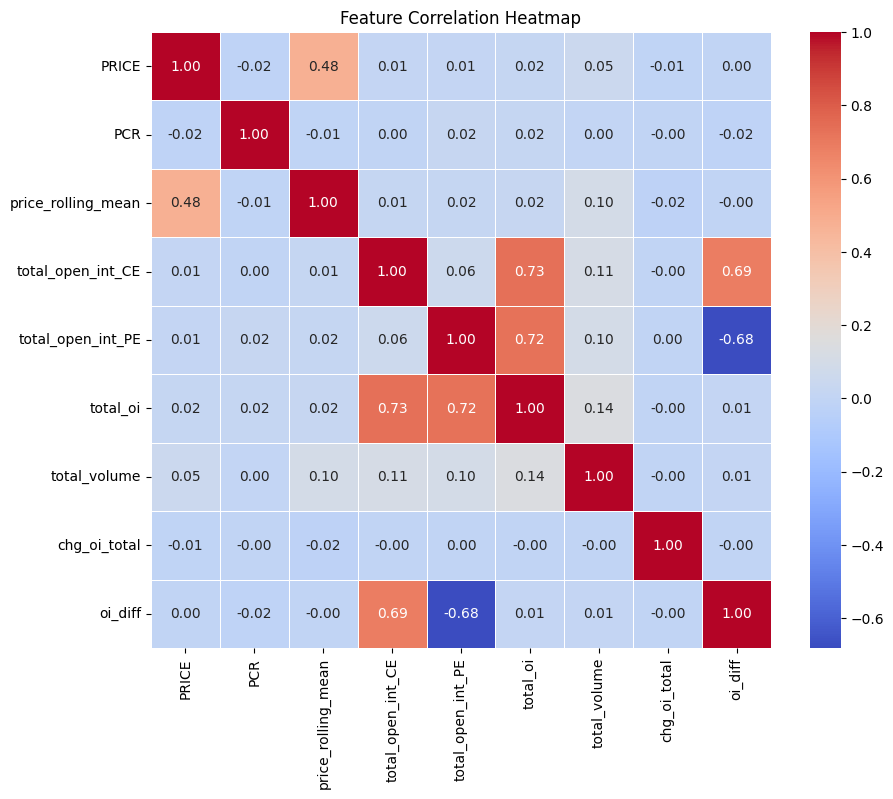

In [82]:
# Correlation heatmap
corr_df = model_df[['PRICE', 'PCR', 'price_rolling_mean', 'total_open_int_CE', 'total_open_int_PE', 'total_oi', 'total_volume', 'chg_oi_total', 'oi_diff']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


## 10. Model And Final Dataset Export

In [87]:
import joblib
joblib.dump(xgb_model, 'xgbost_model.joblib')

['xgbost_model.joblib']

In [88]:
agg_pivot.to_csv('modified_datasset.csv', index = False)

## 11- Initial Testing

In [90]:
def test_model(sample_input):    
    if isinstance(sample_input, dict):
        sample_input = pd.DataFrame([sample_input])
    
    input_data = sample_input[feature_cols]
    
    input_scaled = scaler.transform(input_data)
    
    pred_price = xgb_model.predict(input_scaled)
    
    pred_direction = (pred_price > input_data['PRICE']).astype(int)
    
    return {
        "predicted_price": pred_price,
        "predicted_direction": pred_direction
    }
    


In [91]:
sample = {
    'PCR': 0.9,
    'PRICE': 19500,
    'price_rolling_mean': 19480,
    'total_open_int_CE': 120000,
    'total_open_int_PE': 110000,
    'total_contracts_CE': 50000,
    'total_contracts_PE': 48000,
    'total_oi': 230000,
    'total_volume': 98000,
    'chg_oi_total': 5000,
    'oi_diff': 10000
}

result = test_model(sample)
print(result)

{'predicted_price': array([728.0362], dtype=float32), 'predicted_direction': 0    0
Name: PRICE, dtype: int64}
